Grok

In [6]:
import gurobipy as gp
from gurobipy import GRB
import json
import numpy as np

# Default constants
DEFAULTS = {
    "time_horizon": 24,  # Hours
    "time_step": 1.0,  # Hours
    "ramp_up": 100.0,  # MW
    "ramp_down": 100.0,  # MW
    "startup_limit": 100.0,  # MW
    "shutdown_limit": 100.0,  # MW
    "min_uptime": 1,  # Hours
    "min_downtime": 1,  # Hours
    "normal_limit": 300.0,  # MW
    "emergency_limit": 400.0,  # MW
    "flow_penalty": 1000.0,  # $/MW
    "reserve_penalty": 1000.0,  # $/MW
    "balance_penalty": 10000.0,  # $/MW
    "storage_charge_cost": 2.0,  # $/MW
    "storage_discharge_cost": 2.5,  # $/MW
    "storage_max_level": 100.0,  # MWh
    "storage_charge_rate": 10.0,  # MW
    "storage_discharge_rate": 10.0,  # MW
    "storage_charge_eff": 0.9,  # Fraction
    "storage_discharge_eff": 0.9,  # Fraction
    "storage_loss_factor": 0.0,  # Fraction
    "storage_initial_level": 50.0,  # MWh
}

# Key mappings for alternative JSON keys
KEY_MAPPINGS = {
    "time_horizon": {"Time horizon (h)", "Time (h)"},
    "time_step": {"Time step (min)"},
    "p_mw": {"Production cost curve (MW)", "Maximum power (MW)", "Minimum power (MW)"},
    "p_cost": {"Production cost curve ($)", "Cost ($/MW)"},
    "bus": {"Bus"},
    "type": {"Type"},
    "startup_delays": {"Startup delays (h)"},
    "startup_costs": {"Startup costs ($)"},
    "ramp_up": {"Ramp up limit (MW)"},
    "ramp_down": {"Ramp down limit (MW)"},
    "startup_limit": {"Startup limit (MW)"},
    "shutdown_limit": {"Shutdown limit (MW)"},
    "must_run": {"Must run?"},
    "min_uptime": {"Minimum uptime (h)"},
    "min_downtime": {"Minimum downtime (h)"},
    "initial_status": {"Initial status (h)"},
    "initial_power": {"Initial power (MW)"},
    "reserve_eligibility": {"Reserve eligibility"},
    "commitment_status": {"Commitment status"},
    "load_mw": {"Load (MW)"},
    "source_bus": {"Source bus"},
    "target_bus": {"Target bus"},
    "reactance": {"Reactance (ohms)"},
    "susceptance": {"Susceptance (S)"},
    "normal_limit": {"Normal flow limit (MW)"},
    "emergency_limit": {"Emergency flow limit (MW)"},
    "flow_penalty": {"Flow limit penalty ($/MW)"},
    "reserve_amount": {"Amount (MW)"},
    "reserve_penalty": {"Shortfall penalty ($/MW)", "Reserve shortfall penalty ($/MW)"},
    "storage_min_level": {"Minimum level (MWh)"},
    "storage_max_level": {"Maximum level (MWh)"},
    "storage_charge_cost": {"Charge cost ($/MW)"},
    "storage_discharge_cost": {"Discharge cost ($/MW)"},
    "storage_charge_eff": {"Charge efficiency"},
    "storage_discharge_eff": {"Discharge efficiency"},
    "storage_loss_factor": {"Loss factor"},
    "storage_min_charge_rate": {"Minimum charge rate (MW)"},
    "storage_max_charge_rate": {"Maximum charge rate (MW)"},
    "storage_min_discharge_rate": {"Minimum discharge rate (MW)"},
    "storage_max_discharge_rate": {"Maximum discharge rate (MW)"},
    "storage_initial_level": {"Initial level (MWh)"},
    "storage_last_min_level": {"Last period minimum level (MWh)"},
    "storage_last_max_level": {"Last period maximum level (MWh)"},
    "storage_simultaneous": {"Allow simultaneous charging and discharging"},
    "min_power": {"Minimum power (MW)"},
    "max_power": {"Maximum power (MW)"},
}


def get_key_value(data, key, default=None):
    for alt_key in KEY_MAPPINGS.get(key, {key}):
        if alt_key in data:
            return data[alt_key]
    return default


def ensure_list(param, T, param_name, default=None):
    if isinstance(param, list):
        if len(param) != T:
            raise ValueError(
                f"Parameter '{param_name}': List length ({len(param)}) does not match time stamps ({T})"
            )
        return param
    elif isinstance(param, (int, float)):
        return [param] * T
    else:
        return [default] * T if default is not None else [0] * T


def find_T(data, time_horizon):
    list_lengths = set()
    for bus_id, bus in data.get("Buses", {}).items():
        load_mw = bus.get("Load (MW)", 0.0)
        if isinstance(load_mw, list):
            list_lengths.add(len(load_mw))
    for r_id, res in data.get("Reserves", {}).items():
        amount_mw = res.get("Amount (MW)", 0.0)
        if isinstance(amount_mw, list):
            list_lengths.add(len(amount_mw))
    for s_id, s in data.get("Storage units", {}).items():
        for key in [
            "Minimum level (MWh)",
            "Maximum level (MWh)",
            "Charge cost ($/MW)",
            "Discharge cost ($/MW)",
            "Charge efficiency",
            "Discharge efficiency",
            "Minimum charge rate (MW)",
            "Maximum charge rate (MW)",
            "Minimum discharge rate (MW)",
            "Maximum discharge rate (MW)",
            "Allow simultaneous charging and discharging",
        ]:
            param = s.get(key, None)
            if isinstance(param, list):
                list_lengths.add(len(param))
    if list_lengths:
        if len(list_lengths) > 1:
            raise ValueError("Inconsistent list lengths in data")
        return list_lengths.pop()
    return 1


def validate_data(data):
    errors = []
    warnings = []

    time_horizon = data["parameters"]["time_horizon"]
    time_step = data["parameters"]["time_step"]
    T = int(time_horizon / time_step)

    # Generator validation
    generators = data["generators"]
    for g_id, g in generators.items():
        g_type = g.get("type", "Thermal")
        if g_type not in ["Thermal", "Profiled"]:
            errors.append(f"Generator {g_id}: Invalid type ({g_type})")
        if not g["bus"]:
            errors.append(f"Generator {g_id}: Missing bus assignment")

        if g_type == "Thermal":
            if (
                not isinstance(g["p_mw"], list)
                or not isinstance(g["p_cost"], list)
                or len(g["p_mw"]) != len(g["p_cost"])
            ):
                errors.append(f"Generator {g_id}: Invalid production cost curve")
            if max(g["p_mw"]) <= 0:
                errors.append(
                    f"Generator {g_id}: Maximum capacity is non-positive ({max(g['p_mw'])} MW)"
                )
            if len(g["startup_costs"]) != len(g["startup_delays"]):
                errors.append(f"Generator {g_id}: Mismatched startup costs and delays")
            if g["must_run"] and g["initial_status"] < 0:
                warnings.append(
                    f"Generator {g_id}: Must-run with negative initial status. Setting to 1."
                )
                g["initial_status"] = 1
            if g["ramp_up"] <= 0 or g["ramp_down"] <= 0:
                warnings.append(f"Generator {g_id}: Non-positive ramping limits")
            if g["min_uptime"] < 1 or g["min_downtime"] < 1:
                errors.append(f"Generator {g_id}: Invalid min up/down times")
            if g.get("commitment_status") and (
                len(g["commitment_status"]) != T
                or any(cs not in [True, False, None] for cs in g["commitment_status"])
            ):
                errors.append(f"Generator {g_id}: Invalid commitment status")
        elif g_type == "Profiled":
            if g["min_power"] is None or g["max_power"] is None or g["p_cost"] is None:
                errors.append(
                    f"Generator {g_id}: Missing min_power, max_power, or cost"
                )
            if any(mp > mxp for mp, mxp in zip(g["min_power"], g["max_power"])):
                errors.append(f"Generator {g_id}: min_power exceeds max_power")

    # Bus and load validation
    buses = data["buses"]
    for b_id, b in buses.items():
        if any(l < 0 for l in b["load_mw"]):
            errors.append(f"Bus {b_id}: Negative load values")

    # Transmission line validation
    lines = data["lines"]
    for l_id, line in lines.items():
        if not line["source_bus"] or not line["target_bus"]:
            errors.append(f"Line {l_id}: Missing bus assignment")
        if line["susceptance"] == 0 or line["reactance"] <= 0:
            warnings.append(f"Line {l_id}: Invalid susceptance or reactance")
        if line["normal_limit"] <= 0 or line["emergency_limit"] <= 0:
            warnings.append(f"Line {l_id}: Non-positive flow limits")

    # Storage unit validation
    storage_units = data.get("storage_units", {})
    for s_id, s in storage_units.items():
        if not s["bus"]:
            errors.append(f"Storage {s_id}: Missing bus")
        if any(min_l > max_l for min_l, max_l in zip(s["min_level"], s["max_level"])):
            errors.append(f"Storage {s_id}: Min level exceeds max")

    # Reserve validation
    reserves = data["reserves"]
    for r_id, res in reserves.items():
        if any(r < 0 for r in res["amount_mw"]):
            errors.append(f"Reserve {r_id}: Negative requirement")

    # Capacity vs. demand
    total_capacity = sum(
        max(g["p_mw"]) if g["type"] == "Thermal" else max(g["max_power"])
        for g_id, g in generators.items()
    )
    available_capacity_t0 = sum(
        max(g["p_mw"])
        for g_id, g in generators.items()
        if g["type"] == "Thermal" and (g["must_run"] or g["initial_status"] > 0)
    )
    available_capacity_t0 += sum(
        max(g["max_power"]) for g_id, g in generators.items() if g["type"] == "Profiled"
    )
    max_demand = (
        max(sum(b["load_mw"][t] for b in buses.values()) for t in range(T)) if T else 0
    )
    max_reserve = (
        max(max(res["amount_mw"]) for res in reserves.values()) if reserves else 0
    )
    if total_capacity < max_demand + max_reserve:
        errors.append(f"Insufficient total capacity")
    if available_capacity_t0 < max_demand + max_reserve:
        warnings.append(f"Insufficient initial capacity")

    return (
        errors,
        warnings,
        available_capacity_t0,
        max_demand,
        [res["amount_mw"] for res in reserves.values()][0] if reserves else 0,
    )


def load_case(filepath):
    with open(filepath, "rt") as f:
        data = json.load(f)

    time_horizon = get_key_value(
        data.get("Parameters", {}), "time_horizon", DEFAULTS["time_horizon"]
    )
    time_step_min = data.get("Parameters", {}).get("Time step (min)", None)

    if time_step_min is not None:
        time_step = time_step_min / 60.0
        T = int(time_horizon / time_step)
    else:
        T = find_T(data, time_horizon)
        time_step = time_horizon / T if T > 0 else 1.0

    case_data = {
        "parameters": {
            "time_horizon": time_horizon,
            "time_step": time_step,
        },
        "generators": {},
        "buses": {},
        "lines": {},
        "contingencies": data.get("Contingencies", {}),
        "storage_units": {},
        "reserves": {},
    }

    for gen_id, gen_data in data.get("Generators", {}).items():
        g_type = get_key_value(gen_data, "type", "Thermal")
        if g_type == "Thermal":
            p_mw = get_key_value(gen_data, "p_mw")
            case_data["generators"][gen_id] = {
                "type": g_type,
                "bus": get_key_value(gen_data, "bus"),
                "p_mw": p_mw,
                "p_cost": get_key_value(gen_data, "p_cost"),
                "startup_delays": get_key_value(gen_data, "startup_delays", [1]),
                "startup_costs": get_key_value(gen_data, "startup_costs", [0]),
                "ramp_up": get_key_value(gen_data, "ramp_up", DEFAULTS["ramp_up"]),
                "ramp_down": get_key_value(
                    gen_data, "ramp_down", DEFAULTS["ramp_down"]
                ),
                "startup_limit": get_key_value(
                    gen_data, "startup_limit", DEFAULTS["startup_limit"]
                ),
                "shutdown_limit": get_key_value(
                    gen_data, "shutdown_limit", DEFAULTS["shutdown_limit"]
                ),
                "must_run": get_key_value(gen_data, "must_run", False),
                "min_uptime": get_key_value(
                    gen_data, "min_uptime", DEFAULTS["min_uptime"]
                ),
                "min_downtime": get_key_value(
                    gen_data, "min_downtime", DEFAULTS["min_downtime"]
                ),
                "initial_status": get_key_value(gen_data, "initial_status", 0),
                "initial_power": get_key_value(gen_data, "initial_power", 0),
                "reserve_eligibility": get_key_value(
                    gen_data, "reserve_eligibility", []
                ),
                "commitment_status": get_key_value(gen_data, "commitment_status", None),
            }
        elif g_type == "Profiled":
            min_power = get_key_value(gen_data, "min_power", 0.0)
            max_power = get_key_value(gen_data, "max_power", 0.0)
            p_cost = get_key_value(gen_data, "p_cost", 0.0)
            min_power = ensure_list(
                min_power, T, f"Generator {gen_id} min_power", default=0.0
            )
            max_power = ensure_list(
                max_power, T, f"Generator {gen_id} max_power", default=0.0
            )
            p_cost = ensure_list(p_cost, T, f"Generator {gen_id} p_cost", default=0.0)
            case_data["generators"][gen_id] = {
                "type": g_type,
                "bus": get_key_value(gen_data, "bus"),
                "min_power": min_power,
                "max_power": max_power,
                "p_cost": p_cost,
            }

    for bus_id, bus_data in data.get("Buses", {}).items():
        load_mw = get_key_value(bus_data, "load_mw", 0.0)
        load_mw = ensure_list(load_mw, T, f"Bus {bus_id} load_mw", default=0.0)
        case_data["buses"][bus_id] = {"load_mw": load_mw}

    for line_id, line_data in data.get("Transmission lines", {}).items():
        case_data["lines"][line_id] = {
            "source_bus": get_key_value(line_data, "source_bus"),
            "target_bus": get_key_value(line_data, "target_bus"),
            "reactance": get_key_value(line_data, "reactance", float("inf")),
            "susceptance": get_key_value(line_data, "susceptance", 0.0) / 100,
            "normal_limit": get_key_value(
                line_data, "normal_limit", DEFAULTS["normal_limit"]
            ),
            "emergency_limit": get_key_value(
                line_data, "emergency_limit", DEFAULTS["emergency_limit"]
            ),
            "penalty": get_key_value(
                line_data, "flow_penalty", DEFAULTS["flow_penalty"]
            ),
        }

    for s_id, s_data in data.get("Storage units", {}).items():
        s = {
            "bus": get_key_value(s_data, "bus"),
            "min_level": ensure_list(
                get_key_value(s_data, "storage_min_level", 0.0),
                T,
                f"Storage {s_id} min_level",
                default=0.0,
            ),
            "max_level": ensure_list(
                get_key_value(
                    s_data, "storage_max_level", DEFAULTS["storage_max_level"]
                ),
                T,
                f"Storage {s_id} max_level",
                default=DEFAULTS["storage_max_level"],
            ),
            "charge_cost": ensure_list(
                get_key_value(
                    s_data, "storage_charge_cost", DEFAULTS["storage_charge_cost"]
                ),
                T,
                f"Storage {s_id} charge_cost",
                default=DEFAULTS["storage_charge_cost"],
            ),
            "discharge_cost": ensure_list(
                get_key_value(
                    s_data, "storage_discharge_cost", DEFAULTS["storage_discharge_cost"]
                ),
                T,
                f"Storage {s_id} discharge_cost",
                default=DEFAULTS["storage_discharge_cost"],
            ),
            "charge_eff": ensure_list(
                get_key_value(
                    s_data, "storage_charge_eff", DEFAULTS["storage_charge_eff"]
                ),
                T,
                f"Storage {s_id} charge_eff",
                default=DEFAULTS["storage_charge_eff"],
            ),
            "discharge_eff": ensure_list(
                get_key_value(
                    s_data, "storage_discharge_eff", DEFAULTS["storage_discharge_eff"]
                ),
                T,
                f"Storage {s_id} discharge_eff",
                default=DEFAULTS["storage_discharge_eff"],
            ),
            "loss_factor": get_key_value(
                s_data, "storage_loss_factor", DEFAULTS["storage_loss_factor"]
            ),
            "min_charge_rate": ensure_list(
                get_key_value(s_data, "storage_min_charge_rate", 0.0),
                T,
                f"Storage {s_id} min_charge_rate",
                default=0.0,
            ),
            "max_charge_rate": ensure_list(
                get_key_value(
                    s_data, "storage_max_charge_rate", DEFAULTS["storage_charge_rate"]
                ),
                T,
                f"Storage {s_id} max_charge_rate",
                default=DEFAULTS["storage_charge_rate"],
            ),
            "min_discharge_rate": ensure_list(
                get_key_value(s_data, "storage_min_discharge_rate", 0.0),
                T,
                f"Storage {s_id} min_discharge_rate",
                default=0.0,
            ),
            "max_discharge_rate": ensure_list(
                get_key_value(
                    s_data,
                    "storage_max_discharge_rate",
                    DEFAULTS["storage_discharge_rate"],
                ),
                T,
                f"Storage {s_id} max_discharge_rate",
                default=DEFAULTS["storage_discharge_rate"],
            ),
            "initial_level": get_key_value(
                s_data, "storage_initial_level", DEFAULTS["storage_initial_level"]
            ),
            "last_min_level": get_key_value(s_data, "storage_last_min_level", 0.0),
            "last_max_level": get_key_value(
                s_data, "storage_last_max_level", DEFAULTS["storage_max_level"]
            ),
            "simultaneous": ensure_list(
                get_key_value(s_data, "storage_simultaneous", True),
                T,
                f"Storage {s_id} simultaneous",
                default=True,
            ),
        }
        case_data["storage_units"][s_id] = s

    for r_id, r_data in data.get("Reserves", {}).items():
        amount_mw = get_key_value(r_data, "reserve_amount", 0.0)
        amount_mw = ensure_list(amount_mw, T, f"Reserve {r_id} amount_mw", default=0.0)
        case_data["reserves"][r_id] = {
            "amount_mw": amount_mw,
            "penalty": get_key_value(
                r_data, "reserve_penalty", DEFAULTS["reserve_penalty"]
            ),
        }

    errors, warnings, available_capacity_t0, max_demand, adjusted_reserve = (
        validate_data(case_data)
    )
    if errors:
        raise ValueError("\n".join(errors))
    for warning in warnings:
        print(warning)

    return case_data, available_capacity_t0, max_demand, adjusted_reserve


def build_model(data, available_capacity_t0, max_demand, adjusted_reserve, config):
    model = gp.Model("SCUC")
    time_step = data["parameters"]["time_step"]
    T = range(int(data["parameters"]["time_horizon"] / time_step))
    gens = data["generators"]
    buses = data["buses"]
    lines = data["lines"]
    conts = data["contingencies"]
    reserves = data["reserves"]
    storage_units = data["storage_units"]

    commit = model.addVars(
        [(g_id, t) for g_id, g in gens.items() if g["type"] == "Thermal" for t in T],
        vtype=GRB.BINARY,
        name="commit",
    )
    startup = model.addVars(
        [(g_id, t) for g_id, g in gens.items() if g["type"] == "Thermal" for t in T],
        vtype=GRB.BINARY,
        name="startup",
    )
    shutdown = model.addVars(
        [(g_id, t) for g_id, g in gens.items() if g["type"] == "Thermal" for t in T],
        vtype=GRB.BINARY,
        name="shutdown",
    )
    dispatch = model.addVars(
        [(g_id, t) for g_id, g in gens.items() for t in T], lb=0, name="dispatch"
    )
    reserve = model.addVars(
        [
            (g_id, t)
            for g_id, g in gens.items()
            if g["type"] == "Thermal" and "r1" in g["reserve_eligibility"]
            for t in T
        ],
        lb=0,
        name="reserve",
    )
    theta = model.addVars(buses, T, lb=-GRB.INFINITY, ub=GRB.INFINITY, name="theta")
    reserve_slack = model.addVars(T, lb=0, name="reserve_slack")
    balance_slack = model.addVars(buses, T, lb=0, name="balance_slack")
    charge = model.addVars(storage_units, T, lb=0, name="charge")
    discharge = model.addVars(storage_units, T, lb=0, name="discharge")
    level = model.addVars(storage_units, T, lb=0, name="level")
    charge_binary = model.addVars(
        [
            (s_id, t)
            for s_id, s in storage_units.items()
            if not all(s["simultaneous"])
            for t in T
        ],
        vtype=GRB.BINARY,
        name="charge_binary",
    )

    ref_bus = list(buses.keys())[0]
    for t in T:
        model.addConstr(theta[ref_bus, t] == 0)

    for g_id, g in gens.items():
        if g["type"] == "Thermal":
            p_mw = g["p_mw"]
            p_min, p_max = min(p_mw), max(p_mw)
            for t in T:
                model.addConstr(dispatch[g_id, t] >= p_min * commit[g_id, t])
                model.addConstr(dispatch[g_id, t] <= p_max * commit[g_id, t])
                if "r1" in g["reserve_eligibility"]:
                    model.addConstr(
                        reserve[g_id, t]
                        <= (p_max - dispatch[g_id, t]) * commit[g_id, t]
                    )
                if t > 0:
                    model.addConstr(
                        dispatch[g_id, t] - dispatch[g_id, t - 1]
                        <= g["ramp_up"] * time_step
                    )
                    model.addConstr(
                        dispatch[g_id, t - 1] - dispatch[g_id, t]
                        <= g["ramp_down"] * time_step
                    )
            if not g["must_run"] and available_capacity_t0 >= max_demand + max(
                adjusted_reserve
            ):
                initial_status = g["initial_status"]
                for t in range(
                    min(
                        T[-1] + 1,
                        (
                            int(g["min_downtime"] / time_step)
                            if initial_status < 0
                            else int(g["min_uptime"] / time_step)
                        ),
                    )
                ):
                    model.addConstr(commit[g_id, t] == (0 if initial_status < 0 else 1))
            for t in T:
                if t == 0:
                    initial_on = 1 if g["must_run"] or g["initial_status"] > 0 else 0
                    model.addConstr(startup[g_id, t] >= commit[g_id, t] - initial_on)
                    model.addConstr(shutdown[g_id, t] >= initial_on - commit[g_id, t])
                else:
                    model.addConstr(
                        startup[g_id, t] - shutdown[g_id, t]
                        == commit[g_id, t] - commit[g_id, t - 1]
                    )
            for t in range(int(g["min_uptime"] / time_step) - 1, T[-1] + 1):
                model.addConstr(
                    gp.quicksum(
                        startup[g_id, tau]
                        for tau in range(
                            max(0, t - int(g["min_uptime"] / time_step) + 1), t + 1
                        )
                    )
                    <= commit[g_id, t]
                )
            for t in range(int(g["min_downtime"] / time_step) - 1, T[-1] + 1):
                model.addConstr(
                    gp.quicksum(
                        shutdown[g_id, tau]
                        for tau in range(
                            max(0, t - int(g["min_downtime"] / time_step) + 1), t + 1
                        )
                    )
                    <= 1 - commit[g_id, t]
                )
            if g["must_run"]:
                for t in T:
                    model.addConstr(commit[g_id, t] == 1)
            if g.get("commitment_status"):
                for t in T:
                    if g["commitment_status"][t] is not None:
                        model.addConstr(
                            commit[g_id, t] == (1 if g["commitment_status"][t] else 0)
                        )
        elif g["type"] == "Profiled":
            for t in T:
                model.addConstr(dispatch[g_id, t] >= g["min_power"][t])
                model.addConstr(dispatch[g_id, t] <= g["max_power"][t])

    for s_id, s in storage_units.items():
        for t in T:
            model.addConstr(charge[s_id, t] >= s["min_charge_rate"][t])
            model.addConstr(charge[s_id, t] <= s["max_charge_rate"][t])
            model.addConstr(discharge[s_id, t] >= s["min_discharge_rate"][t])
            model.addConstr(discharge[s_id, t] <= s["max_discharge_rate"][t])
            model.addConstr(level[s_id, t] >= s["min_level"][t])
            model.addConstr(level[s_id, t] <= s["max_level"][t])
            if not s["simultaneous"][t]:
                model.addConstr(
                    charge[s_id, t] <= s["max_charge_rate"][t] * charge_binary[s_id, t]
                )
                model.addConstr(
                    discharge[s_id, t]
                    <= s["max_discharge_rate"][t] * (1 - charge_binary[s_id, t])
                )
        for t in T:
            if t == 0:
                model.addConstr(
                    level[s_id, t]
                    == s["initial_level"] * (1 - s["loss_factor"])
                    + (
                        s["charge_eff"][t] * charge[s_id, t]
                        - discharge[s_id, t] / s["discharge_eff"][t]
                    )
                    * time_step
                )
            else:
                model.addConstr(
                    level[s_id, t]
                    == level[s_id, t - 1] * (1 - s["loss_factor"])
                    + (
                        s["charge_eff"][t] * charge[s_id, t]
                        - discharge[s_id, t] / s["discharge_eff"][t]
                    )
                    * time_step
                )
        if s["last_min_level"] is not None and s["last_max_level"] is not None:
            model.addConstr(level[s_id, T[-1]] >= s["last_min_level"])
            model.addConstr(level[s_id, T[-1]] <= s["last_max_level"])

    for t in T:
        for b_id in buses:
            gen_sum = gp.quicksum(
                dispatch[g_id, t] for g_id, g in gens.items() if g["bus"] == b_id
            )
            storage_sum = gp.quicksum(
                discharge[s_id, t] - charge[s_id, t]
                for s_id, s in storage_units.items()
                if s["bus"] == b_id
            )
            load = buses[b_id]["load_mw"][t]
            inflow = (
                gp.quicksum(
                    (
                        line["susceptance"]
                        * (theta[line["source_bus"], t] - theta[line["target_bus"], t])
                        if line["target_bus"] == b_id
                        else line["susceptance"]
                        * (theta[line["target_bus"], t] - theta[line["source_bus"], t])
                    )
                    for line in lines.values()
                    if line["source_bus"] == b_id or line["target_bus"] == b_id
                )
                if lines
                else 0.0
            )
            model.addConstr(
                gen_sum + storage_sum + inflow + balance_slack[b_id, t] == load
            )

    if lines and conts:
        for cont_name in ["base_case"] + list(conts.keys()):
            for l_id, line in lines.items():
                if cont_name != "base_case" and l_id in conts[cont_name].get(
                    "Affected lines", []
                ):
                    continue
                limit = (
                    line["normal_limit"]
                    if cont_name == "base_case"
                    else line["emergency_limit"]
                )
                for t in T:
                    flow = line["susceptance"] * (
                        theta[line["source_bus"], t] - theta[line["target_bus"], t]
                    )
                    model.addConstr(flow <= limit)
                    model.addConstr(flow >= -limit)
    elif lines:
        for l_id, line in lines.items():
            for t in T:
                flow = line["susceptance"] * (
                    theta[line["source_bus"], t] - theta[line["target_bus"], t]
                )
                model.addConstr(flow <= line["normal_limit"])
                model.addConstr(flow >= -line["normal_limit"])

    for r_id, res in reserves.items():
        eligible_gens = [
            g_id
            for g_id, g in gens.items()
            if g["type"] == "Thermal"
            and g.get("reserve_eligibility", [])
            and "r1" in g["reserve_eligibility"]
        ]
        for t in T:
            if eligible_gens:
                model.addConstr(
                    gp.quicksum(reserve[g, t] for g in eligible_gens)
                    >= res["amount_mw"][t] - reserve_slack[t]
                )

    total_cost = gp.LinExpr()
    for g_id, g in gens.items():
        if g["type"] == "Thermal":
            p_mw = g["p_mw"]
            p_cost = g["p_cost"]
            for t in T:
                for i in range(1, len(p_mw)):
                    seg_lb, seg_ub = p_mw[i - 1], p_mw[i]
                    slope = (p_cost[i] - p_cost[i - 1]) / (seg_ub - seg_lb)
                    seg = model.addVar(lb=0, ub=seg_ub - seg_lb)
                    model.addConstr(
                        seg
                        <= dispatch[g_id, t]
                        - seg_lb * commit[g_id, t]
                        + (seg_ub - seg_lb) * (1 - commit[g_id, t])
                    )
                    model.addConstr(seg >= 0)
                    model.addConstr(dispatch[g_id, t] >= seg_lb * commit[g_id, t])
                    total_cost += slope * seg
                total_cost += g["startup_costs"][0] * startup[g_id, t]
        elif g["type"] == "Profiled":
            for t in T:
                total_cost += g["p_cost"][t] * dispatch[g_id, t]

    for s_id, s in storage_units.items():
        for t in T:
            total_cost += (
                s["charge_cost"][t] * charge[s_id, t]
                + s["discharge_cost"][t] * discharge[s_id, t]
            )

    for t in T:
        total_cost += reserve_slack[t] * reserves.get("r1", {}).get(
            "penalty", DEFAULTS["reserve_penalty"]
        )
    for b_id in buses:
        for t in T:
            total_cost += balance_slack[b_id, t] * DEFAULTS["balance_penalty"]

    model.setObjective(total_cost, GRB.MINIMIZE)
    model.Params.TimeLimit = config["time_limit"]
    model.Params.MIPGap = config["mip_gap"]
    model.Params.Threads = 16
    model.Params.NumericFocus = 3
    if not config["verbose"]:
        model.Params.OutputFlag = 0

    return model, {
        "commit": commit,
        "dispatch": dispatch,
        "reserve": reserve,
        "theta": theta,
        "reserve_slack": reserve_slack,
        "balance_slack": balance_slack,
        "charge": charge,
        "discharge": discharge,
        "level": level,
    }


def solve_model(model):
    model.optimize()
    if model.status in [GRB.OPTIMAL, GRB.SUBOPTIMAL]:
        solution = {v.VarName: v.X for v in model.getVars()}
        return {"status": model.status, "solution": solution, "objective": model.ObjVal}
    if model.status == GRB.INFEASIBLE:
        model.computeIIS()
        model.write("scuc_model.ilp")
        print("Model infeasible. IIS written to scuc_model.ilp")

        # Print infeasibility summary for model validation
        print("Model validation (IIS):")
        for c in model.getConstrs():
            if c.IISConstr:
                print(f"Infeasible constraint: {c.ConstrName}")
        for v in model.getVars():
            if v.IISLB:
                print(f"Infeasible lower bound: {v.VarName}")
            if v.IISUB:
                print(f"Infeasible upper bound: {v.VarName}")
    return {"status": model.status, "solution": None, "objective": None}


if __name__ == "__main__":
    config = {"time_limit": 120, "mip_gap": 0.1, "verbose": True}
    try:
        data, available_capacity_t0, max_demand, adjusted_reserve = load_case(
            "case118-initcond.json"
        )
        model, vars = build_model(
            data, available_capacity_t0, max_demand, adjusted_reserve, config
        )
        solution = solve_model(model)
        if solution["solution"]:
            print(f"Objective: {solution['objective']:.2f}")
            for var_name, var_value in solution["solution"].items():
                if "dispatch" in var_name and var_value > 1e-3:
                    print(f"{var_name}: {var_value:.2f} MW")
                if "commit" in var_name and var_value > 0.5:
                    print(f"{var_name}: {var_value:.0f}")
                if "reserve_slack" in var_name and var_value > 1e-3:
                    print(f"{var_name}: {var_value:.2f} MW")
                if "balance_slack" in var_name and var_value > 1e-3:
                    print(f"{var_name}: {var_value:.2f} MW")
                if "charge" in var_name and var_value > 1e-3:
                    print(f"{var_name}: {var_value:.2f} MW")
                if "discharge" in var_name and var_value > 1e-3:
                    print(f"{var_name}: {var_value:.2f} MW")
                if "level" in var_name:
                    print(f"{var_name}: {var_value:.2f} MWh")
    except ValueError as e:
        print(f"Error: {e}")

Insufficient initial capacity
Set parameter TimeLimit to value 120
Set parameter MIPGap to value 0.1
Set parameter Threads to value 16
Set parameter NumericFocus to value 3
Gurobi Optimizer version 12.0.1 build v12.0.1rc0 (win64 - Windows 11.0 (22631.2))

CPU model: AMD Ryzen 7 7840HS with Radeon 780M Graphics, instruction set [SSE2|AVX|AVX2|AVX512]
Thread count: 8 physical cores, 16 logical processors, using up to 16 threads

Non-default parameters:
TimeLimit  120
MIPGap  0.1
NumericFocus  3
Threads  16

Optimize a model with 2412100 rows, 26028 columns and 4848822 nonzeros
Model fingerprint: 0xbf711716
Model has 1944 quadratic constraints
Variable types: 20196 continuous, 5832 integer (5832 binary)
Coefficient statistics:
  Matrix range     [4e-02, 8e+02]
  QMatrix range    [1e+00, 1e+00]
  QLMatrix range   [1e+00, 8e+02]
  Objective range  [3e+01, 5e+04]
  Bounds range     [1e+00, 2e+02]
  RHS range        [1e+00, 6e+02]
Presolve removed 2376128 rows and 12042 columns
Presolve time:

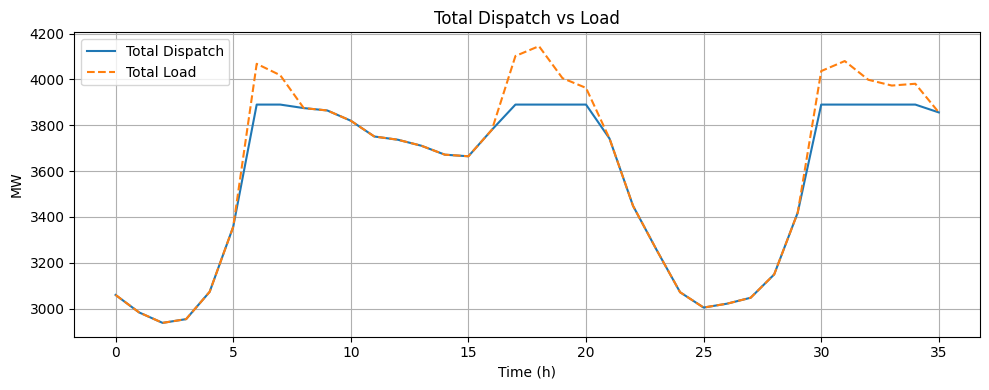

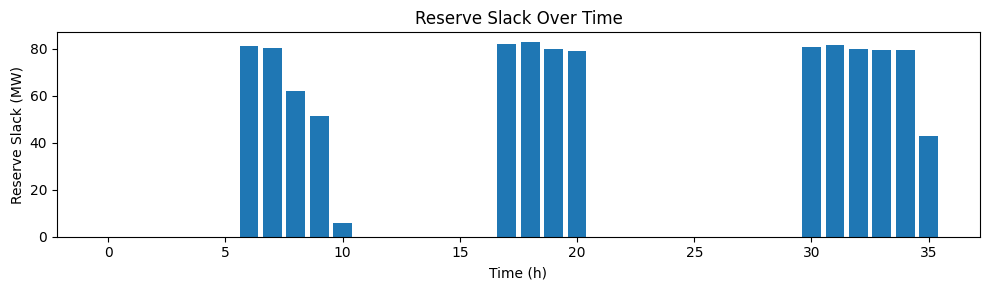

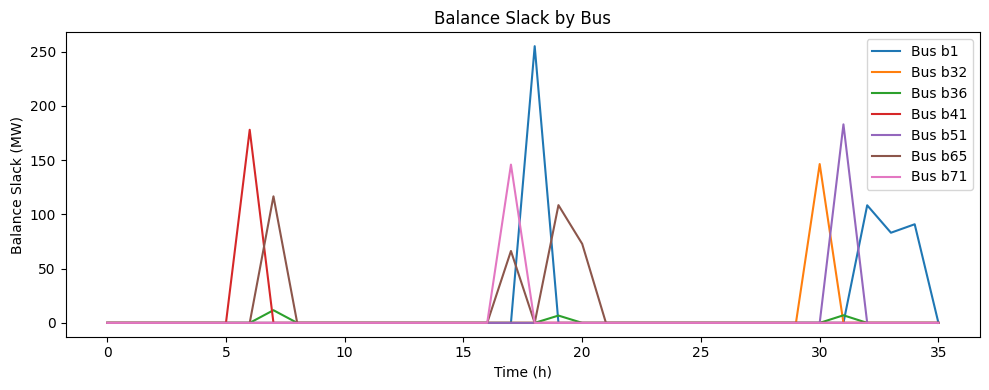

In [8]:
import numpy as np

import matplotlib.pyplot as plt

# Plot total dispatch over time
T = int(data["parameters"]["time_horizon"] / data["parameters"]["time_step"])
time = np.arange(T)

# Sum dispatch for all generators at each time step
total_dispatch = np.zeros(T)
for (g_id, t), var in vars["dispatch"].items():
    total_dispatch[t] += var.X

plt.figure(figsize=(10, 4))
plt.plot(time, total_dispatch, label="Total Dispatch")
plt.plot(
    time,
    [sum(b["load_mw"][t] for b in data["buses"].values()) for t in time],
    label="Total Load",
    linestyle="--",
)
plt.xlabel("Time (h)")
plt.ylabel("MW")
plt.title("Total Dispatch vs Load")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Plot reserve slack over time if present
if vars["reserve_slack"]:
    reserve_slack = [vars["reserve_slack"][t].X for t in time]
    plt.figure(figsize=(10, 3))
    plt.bar(time, reserve_slack)
    plt.xlabel("Time (h)")
    plt.ylabel("Reserve Slack (MW)")
    plt.title("Reserve Slack Over Time")
    plt.tight_layout()
    plt.show()

# Plot balance slack for each bus (sum over time)
bus_slack = {b: [vars["balance_slack"][(b, t)].X for t in time] for b in data["buses"]}
plt.figure(figsize=(10, 4))
for b, slack in bus_slack.items():
    if any(s > 1e-3 for s in slack):
        plt.plot(time, slack, label=f"Bus {b}")
plt.xlabel("Time (h)")
plt.ylabel("Balance Slack (MW)")
plt.title("Balance Slack by Bus")
plt.legend()
plt.tight_layout()
plt.show()